# Classification Exploration

Exploring the dataset and variables to see if using a classification model would be apropriate to answer the predictive question

In [27]:
library(tidyverse)
library(repr)
library(tidymodels)

In [61]:
players <- read_csv("https://raw.githubusercontent.com/YodawgYT/Assignment-Project-Final-Report---GROUP-39---DSCI-100/refs/heads/main/data/players.csv") |>
        mutate(subscribe = as_factor(subscribe), age = Age) |>
        filter(!is.na(age)) |>
        filter(played_hours>0) |>
        mutate(experience = as.numeric(factor(experience, levels = c("Beginner", "Amateur", "Regular", "Veteran", "Pro")))) |>
        select(experience, subscribe, played_hours, age)

head(players)
nrow(players)

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,played_hours,age
<dbl>,<fct>,<dbl>,<dbl>
5,TRUE,30.3,9
4,TRUE,3.8,17
2,TRUE,0.7,21
3,TRUE,0.1,21
2,TRUE,0.1,47
4,TRUE,1.6,23


[1] 109

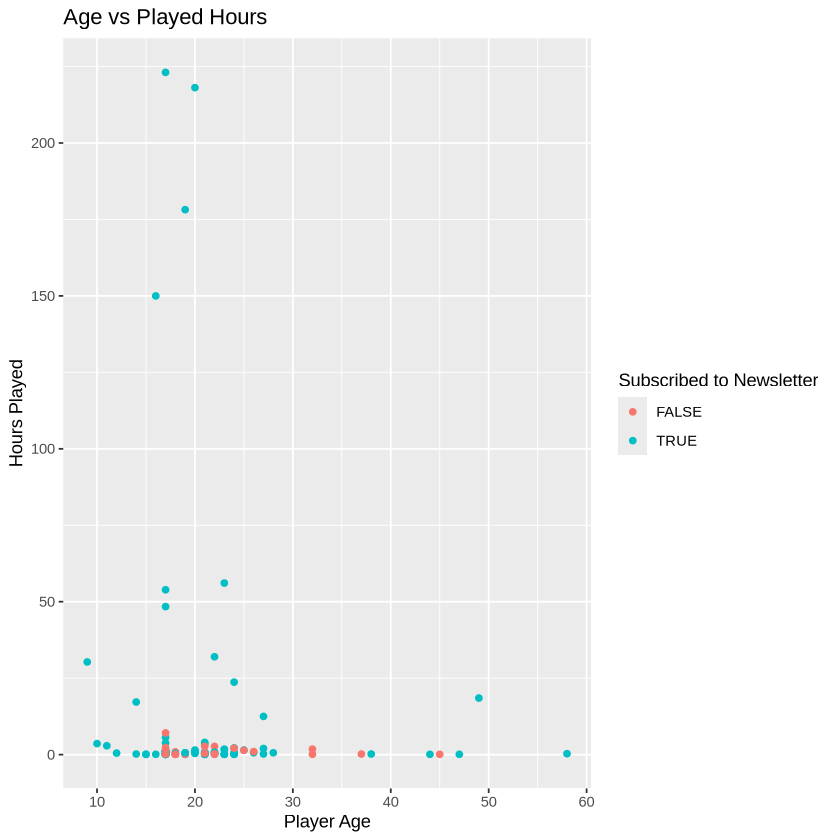

In [62]:
players_plot1 <- players |>
        ggplot(aes(x = age, y = played_hours, color = subscribe)) +
        geom_point() +
        labs(x = "Player Age",
             y = "Hours Played",
             color = "Subscribed to Newsletter",
             title = "Age vs Played Hours")
players_plot1

In [63]:
set.seed(99)
players_split <- initial_split(players, prop = .75, strata = subscribe)
players_training <- training(players_split)
players_testing <- testing(players_split)

neighbors,.metric,mean
<dbl>,<chr>,<dbl>
1,accuracy,0.6133333
2,accuracy,0.6133333
3,accuracy,0.7270588
4,accuracy,0.7270588
5,accuracy,0.7286275
6,accuracy,0.7286275
7,accuracy,0.7788235
8,accuracy,0.7654902
9,accuracy,0.7788235


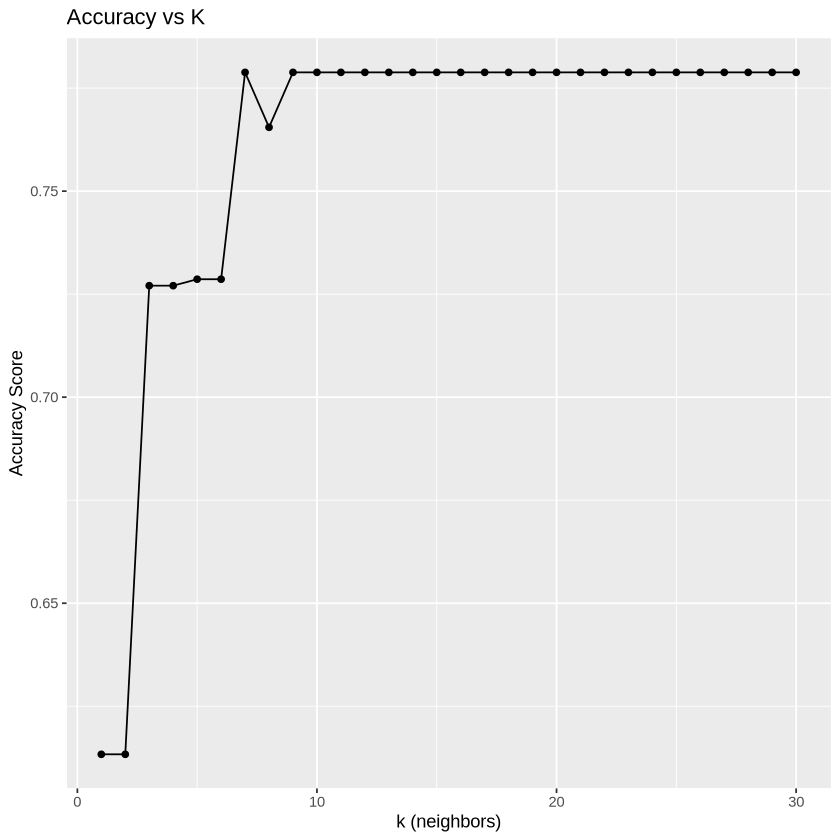

In [64]:
set.seed(99)
players_recipe <- recipe(subscribe ~ ., data = players_training) |>
                    step_center(all_predictors()) |>
                    step_scale(all_predictors())

players_folds <- vfold_cv(players_training, v = 5, strata = subscribe)

knn_tune <- nearest_neighbor(weight_func = "rectangular", neighbors = tune()) |>
set_engine("kknn") |>
set_mode("classification")

k_vals <- tibble(neighbors = seq(from = 1, to = 30, by = 1))

players_fit <- workflow() |>
add_recipe(players_recipe) |>
add_model(knn_tune) |>
tune_grid(resamples = players_folds, grid = k_vals) |>
collect_metrics()

accuracies <- players_fit |>
filter(.metric == "accuracy")|>
select(neighbors, .metric, mean)
accuracies

cross_val_plot <- ggplot(accuracies, aes(x = neighbors, y = mean) ) +
geom_point () +
geom_line() +
labs (x = "k (neighbors)", y = "Accuracy Score", title = "Accuracy vs K")
cross_val_plot

In [65]:
set.seed(99)

players_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = 9) |>
set_engine("kknn") |>
set_mode("classification")

players_fit_best <-workflow() |>
add_recipe(players_recipe) |>
add_model(players_spec) |>
fit(players_training)

players_predictions <- predict(players_fit_best, players_testing) |>
                    bind_cols(players_testing)

players_metrics <- players_predictions |>
     metrics(truth = subscribe, estimate = .pred_class) |>
     filter(.metric == "accuracy")
players_metrics

players_conf_mat <- players_predictions |>
     conf_mat(truth = subscribe, estimate = .pred_class)
players_conf_mat

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.8214286


          Truth
Prediction FALSE TRUE
     FALSE     2    0
     TRUE      5   21